# Tutorial to correlation for signal detection and timing

## Timing Jitter and its effects to signal peak detection

**Definition:** The timing offset from the true onset of seizure at the electrode.

---

## Correlation for Detecting Signal in AWGN

### Fundamentals of Correlation

Correlation is the optimal detection method for a known signal in additive white Gaussian noise (AWGN). The process involves comparing the received signal with a known template or reference signal to determine the arrival time.

**Correlation Function:**

For continuous signals, the cross-correlation between received signal $r(t)$ and template $s(t)$ is:

$$
R_{rs}(\tau) = \int_{-\infty}^{\infty} r(t) \cdot s(t - \tau) \, dt
$$

For discrete-time signals (sampled at intervals $T_s$):

$$
R_{rs}[m] = \sum_{n=-\infty}^{\infty} r[n] \cdot s[n - m]
$$

where $\tau = mT_s$ is the time delay being tested.


### Signal Model in AWGN

The received signal at an electrode can be modeled as:

$$
r(t) = s(t - t_0) + n(t)
$$

where:
- $s(t)$ is the known IED (Interictal Epileptiform Discharge) template signal
- $t_0$ is the true (but unknown) arrival time we wish to estimate
- $n(t)$ is thermal noise, modeled as $n(t) \sim \mathcal{N}(0, \sigma_n^2)$


### Correlation Output Under Noise

Substituting the signal model into the correlation function:

$$
R_{rs}(\tau) = \int_{-\infty}^{\infty} [s(t - t_0) + n(t)] \cdot s(t - \tau) \, dt
$$

$$
R_{rs}(\tau) = \int_{-\infty}^{\infty} s(t - t_0) \cdot s(t - \tau) \, dt + \int_{-\infty}^{\infty} n(t) \cdot s(t - \tau) \, dt
$$

$$
R_{rs}(\tau) = R_{ss}(\tau - t_0) + N(\tau)
$$

where:
- $R_{ss}(\tau - t_0)$ is the autocorrelation of the signal, shifted to peak at $\tau = t_0$
- $N(\tau)$ is a random noise component with zero mean

**Without noise:** The correlation peaks exactly at $\tau = t_0$

**With noise:** The estimated peak location $\hat{t}_0$ is perturbed from the true value $t_0$, creating timing jitter.


### Detection Theory and the Cramér-Rao Lower Bound

The Cramér-Rao Lower Bound (CRLB) establishes the fundamental limit on timing estimation accuracy. For estimating the arrival time $$t_0$$ of a signal in AWGN, the variance of any unbiased estimator satisfies:

$$
\sigma_t^2 \geq \text{CRLB} = \frac{1}{8\pi^2 \beta^2 \cdot \text{SNR}}
$$

where:
- $\sigma_t^2$ is the variance of the timing estimate (jitter variance)
- $\beta$ is the RMS (root-mean-square) bandwidth of the signal
- $\text{SNR}$ is the signal-to-noise ratio

**Alternative formulation using signal spectrum:**

$$
\sigma_t^2 \geq \frac{1}{(2\pi)^2 \cdot \text{SNR} \cdot \int_{-\infty}^{\infty} f^2 |S(f)|^2 \, df}
$$

where $S(f)$ is the Fourier transform of the signal $s(t)$, normalized such that $\int_{-\infty}^{\infty} |S(f)|^2 \, df = 1$.


### SNR Definitions and Relationships

**Input SNR:**

$$
\text{SNR}_{\text{in}} = \frac{E_s}{N_0} = \frac{\int_{-\infty}^{\infty} s^2(t) \, dt}{\sigma_n^2}
$$

where $E_s$ is the signal energy and $N_0 = \sigma_n^2$ is the noise power spectral density (for white noise).

**Output SNR at correlation peak:**

The matched filter (correlator) provides an SNR improvement:

$$
\text{SNR}_{\text{out}} = 2 \cdot \text{SNR}_{\text{in}} \cdot \text{TBW}
$$

where $\text{TBW} = T \cdot B$ is the time-bandwidth product ($T$ = signal duration, $B$ = bandwidth).

### Key Insights from Detection Theory

1. **Optimal detector:** Correlation (matched filtering) maximizes SNR and minimizes timing error variance
2. **Jitter decreases with SNR:** Higher signal power or lower noise power reduces timing uncertainty
3. **Bandwidth matters:** Signals with larger bandwidth yield better timing resolution (smaller $$\sigma_t$$)
4. **Fundamental limit:** Even with optimal processing, thermal noise imposes a lower bound on timing accuracy

### Practical Application: GCC-PHAT

The **Generalized Cross-Correlation with Phase Transform (GCC-PHAT)** is an advanced correlation technique that can provide improved timing estimation in certain conditions:

$$
R_{\text{PHAT}}(\tau) = \int_{-\infty}^{\infty} \frac{R_{rs}(f)}{|R_{rs}(f)|} e^{j2\pi f \tau} \, df
$$

This method whitens the spectrum and can be more robust to reverberation and frequency-dependent distortions, though its benefits depend on the specific noise and signal characteristics.


---

## Affects of Jitter on Timing Problems

### Impact of Thermal Noise on Timing

Thermal noise causes the correlation peak to fluctuate around the true signal arrival time. The key effects are:

**1. Peak Location Variance:**
- The detected peak time $\hat{t}_0$ is a random variable distributed around $t_0$
- For high SNR and Gaussian noise: $\hat{t}_0 \sim \mathcal{N}(t_0, \sigma_t^2)$
- The standard deviation $\sigma_t$ represents the timing jitter

**2. SNR-Dependent Jitter:**
- Lower SNR → larger timing uncertainty
- The relationship is inverse: $\sigma_t \propto 1/\sqrt{\text{SNR}}$

**3. Bandwidth-Dependent Resolution:**
- Wider bandwidth signals → sharper correlation peaks → better timing resolution
- Narrowband signals have broader correlation peaks, making peak localization less precise

### Propagation Effects and Multipath

**Multipath Propagation:**

Multipath refers to the phenomenon where the transmitted signal reaches the receiver via multiple paths due to reflections off walls, floors, or other structures. This creates multiple delayed and attenuated copies of the signal.

**Mathematical Model:**

The received signal under multipath conditions:

$$
r(t) = \sum_{k=0}^{K-1} \alpha_k s(t - t_0 - \tau_k) + n(t)
$$

where:
- $\alpha_k$ is the attenuation coefficient of path $k$
- $\tau_k$ is the relative delay of path $k$
- $K$ is the number of propagation paths

**Effect on Correlation:**

The correlation function becomes:

$$
R_{rs}(\tau) = \sum_{k=0}^{K-1} \alpha_k R_{ss}(\tau - t_0 - \tau_k) + N(\tau)
$$

This creates multiple peaks or a distorted peak shape, degrading timing estimation accuracy.

**Application to Seizure Detection:**

For this specific application:
- **Electrode spacing:** < 0.3 mm
- **Propagation speed in brain tissue:** ~350 mm/s
- **Signal bandwidth:** < 2 kHz
- **Maximum propagation time difference:** $\Delta t = \frac{0.3 \text{ mm}}{350 \text{ mm/s}} \approx 0.86 \text{ ms}$

**Analysis:**

Given that the wavelength at 2 kHz is:

$$
\lambda = \frac{v}{f} = \frac{350 \text{ mm/s}}{2000 \text{ Hz}} = 0.175 \text{ mm}
$$

The electrode spacing is only ~1.7 wavelengths. Therefore:
- Multipath delays ($< 0.86$ ms) are small relative to the signal period
- All electrodes in the small array experience similar multipath distortion
- The signal will be distorted, but the distortion should be **nearly identical** across all electrodes
- **Conclusion:** Propagation effects can be considered negligible for relative timing between electrodes

### Combined Effects on Timing Accuracy

The observed timing jitter results from:

1. **Thermal noise** perturbing the correlation peak location (fundamental limit)
2. **Multipath interference** distorting the correlation peak shape (negligible for small arrays)
3. **Other sources** (discussed in next section)

For the seizure detection application, thermal noise is expected to be the dominant source of timing jitter between closely-spaced electrodes.

---

## Other Causes of Jitter (Beyond this Tutorial's Scope)

### 3. Interference - Non-random, Non-IED Waveforms

**Description:**
- Different propagating signals (other brain activity, artifacts) affect array electrodes differently due to phase differences in the interfering signal
- **Likely the main cause of timing differences between electrodes** in brain signal processing
- Unlike thermal noise, interference is structured and may have spatial coherence

**Potential Solutions (for reference):**

**MVDR (Minimum Variance Distortionless Response):**
- Angle-of-Arrival (AoA) selection based on signal power
- Determines angles of arrival based on coherent power coming from all directions
- Could be useful as a preliminary step, especially if multiple 1-minute samples contain IEDs
- Has interesting applications for this problem

**MUSIC (Multiple Signal Classification):**
- Uses eigendecomposition to separate signal and noise subspaces
- Attempts multiple angles of arrival
- Performs correlation on channels after filtering out "components with least information"
- May be interesting for analysis, though direct applicability depends on detection framework

**Note:** These techniques may help mitigate interference but require multiple snapshots and assumptions about signal/interference structure.

### 4. Synchronization Errors

**Description:**
- In radio systems, estimators for phase-locked loops or symbol timing are imperfect
- Synchronization algorithms attempt to align receiver timing with transmitter, but errors remain

**Challenge for Seizure Detection:**
- There are **no prior symbols or established knowledge** of the exact IED waveform shape
- The IED is not a transmitted signal with known timing structure
- **Importance depends on the specific detection algorithm employed**
- If using template matching, uncertainty in the template itself could be considered a form of synchronization error

**Assessment:** Likely not a significant factor unless implementing advanced coherent detection schemes.

### 5. Oscillator Instability

**Description:**
- Clocks in signal processing systems are imperfect and can drift over time
- Different oscillators can drift relative to each other (clock skew)
- Frequency instability creates time-varying sampling rates

**Mitigation for This Application:**
- **Assume all electrodes are connected to the same system clock**
- This removes issues from oscillator instability because all channels are affected equally
- **Assume path delays from clock to electrodes are very short** (< ns range for typical PCB layouts)
- Any clock drift affects all channels identically, preserving relative timing

**Conclusion:** Can be safely neglected for multi-channel systems with common clock distribution.

### 6. ADC Jitter

**Description:**
- Analog-to-Digital Converters can sample at improper times due to aperture jitter
- The sampling clock itself has phase noise
- Creates uncertainty in the actual sampling instant

**Quantifying ADC Jitter:**

The timing uncertainty due to ADC jitter adds variance:

$$
\sigma_{\text{total}}^2 = \sigma_t^2 + \sigma_{\text{ADC}}^2
$$

**Relevance:**
- ADC jitter is primarily an issue for **high sampling rate systems** (GHz+ ranges) or **high-frequency signals**
- For this application operating at **sub-2 kHz bandwidth**, ADC jitter is negligible
- Typical ADC aperture jitter: ~1-100 ps
- Signal period at 2 kHz: ~500 μs
- **Jitter-to-signal ratio:** $$\frac{100 \text{ ps}}{500 \text{ μs}} \approx 0.0002\%$$

**Conclusion:** ADC jitter can be skipped as a concern for this application.

---

## Side Notes

**Question for Future Exploration:**  
How does electrode degradation affect signal collection - could it be frequency selective?

- Electrode impedance may increase with degradation
- Could act as a frequency-dependent filter
- May affect high-frequency components more than low-frequency
- Worth investigating if electrode aging impacts detection performance

###  Small introduction to blind detection:


#### Python imports
Prior to beginning this jupyter-notebook tutorial, we can include some python imports.

include the signature of a signal class

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq, fftshift
from dataclasses import dataclass
from typing import Optional

### IED Signal Generator and Init Parameters

In [39]:
# @title
"""
IED (Interictal Epileptiform Discharge) Waveform Generator
Based on IFCN Criteria (Kural et al., Neurology 2020)
Simple class for generating synthetic IED waveforms with customizable parameters.
"""

@dataclass
class IEDParams:
    """Parameters for generating an IED waveform"""

    # Spike component
    spike_amplitude: float = 150.0      # Microvolts (µV)
    spike_duration: float = 70.0        # Milliseconds (ms)
    rise_time: float = 20.0             # Time to peak (ms)
    fall_time: float = 50.0             # Time from peak (ms)
    sharpness: float = 2.0              # Higher = sharper peak

    # Slow wave component
    slow_wave_amplitude: float = 80.0   # µV (relative to spike)
    slow_wave_duration: float = 200.0   # ms

    # Background
    background_freq: float = 10.0       # Hz (e.g., alpha rhythm)
    background_amplitude: float = 50.0  # µV

    # Noise
    noise_level: float = 5.0            # µV

    # Polarity
    negative_spike: bool = True         # True for negative spike


class IEDWaveformGenerator:
    """
    Generate synthetic IED waveforms with customizable morphology.

    Example:
        >>> gen = IEDWaveformGenerator(sampling_rate=256)
        >>>
        >>> # Generate a typical sharp spike
        >>> params = IEDParams(spike_amplitude=150, rise_time=20, fall_time=50)
        >>> time, waveform = gen.generate(params, duration=1.0)
        >>>
        >>> # Generate a slower spike
        >>> params_slow = IEDParams(spike_amplitude=120, rise_time=40, fall_time=100)
        >>> time, waveform = gen.generate(params_slow, duration=1.0)
    """

    def __init__(self, sampling_rate: int = 256):
        """
        Args:
            sampling_rate: Sampling frequency in Hz (default: 256 Hz)
        """
        self.sampling_rate = sampling_rate

    def generate(self,
                 params: IEDParams,
                 duration: float = 1.0,
                 spike_time: Optional[float] = None,
                 baseline_before: Optional[float] = None,
                 baseline_after: Optional[float] = None) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate an IED waveform

        Args:
            params: IED parameters
            duration: Total duration in seconds
            spike_time: Time of spike peak (default: middle of epoch)
            baseline_before: Duration of baseline before spike (overrides spike_time if provided)
            baseline_after: Duration of baseline after spike (overrides duration if provided)

        Returns:
            (time_array, waveform)
        """
        # Handle baseline timing
        if baseline_before is not None:
            spike_time = baseline_before
            if baseline_after is not None:
                # Calculate total duration needed
                spike_duration = (params.fall_time + params.slow_wave_duration) / 1000.0
                duration = baseline_before + spike_duration + baseline_after
        elif spike_time is None:
            spike_time = duration / 2

        n_samples = int(duration * self.sampling_rate)
        time = np.linspace(0, duration, n_samples)

        # Initialize waveform with background activity
        waveform = self._generate_background(time, params)

        # Add spike
        spike = self._generate_spike(time, spike_time, params)
        waveform += spike

        # Add slow wave
        slow_wave = self._generate_slow_wave(time, spike_time, params)
        waveform += slow_wave

        # Add noise
        noise = np.random.normal(0, params.noise_level, n_samples)
        waveform += noise

        return time, waveform

    def _generate_spike(self,
                       time: np.ndarray,
                       peak_time: float,
                       params: IEDParams) -> np.ndarray:
        """Generate the spike component"""
        spike = np.zeros_like(time)

        # Convert times to seconds
        rise_time_sec = params.rise_time / 1000.0
        fall_time_sec = params.fall_time / 1000.0

        # Rising phase (before peak)
        rising_mask = time < peak_time
        if np.any(rising_mask):
            t_rise = time[rising_mask]
            # Exponential rise with sharpness control
            spike[rising_mask] = params.spike_amplitude * np.exp(
                -((peak_time - t_rise) / rise_time_sec) ** params.sharpness
            )

        # Falling phase (after peak)
        falling_mask = time >= peak_time
        if np.any(falling_mask):
            t_fall = time[falling_mask]
            # Exponential decay
            spike[falling_mask] = params.spike_amplitude * np.exp(
                -((t_fall - peak_time) / fall_time_sec) ** (params.sharpness * 0.7)
            )

        # Apply polarity
        if params.negative_spike:
            spike = -spike

        return spike

    def _generate_slow_wave(self,
                           time: np.ndarray,
                           spike_time: float,
                           params: IEDParams) -> np.ndarray:
        """Generate the slow after-wave component"""
        slow_wave = np.zeros_like(time)

        # Slow wave starts after the spike
        slow_duration_sec = params.slow_wave_duration / 1000.0
        slow_start = spike_time + (params.fall_time / 1000.0)

        # Create slow wave (opposite polarity to spike)
        slow_mask = (time >= slow_start) & (time < slow_start + slow_duration_sec)
        if np.any(slow_mask):
            t_slow = time[slow_mask]
            # Gaussian-like slow wave
            center = slow_start + slow_duration_sec / 2
            sigma = slow_duration_sec / 4
            slow_wave[slow_mask] = params.slow_wave_amplitude * np.exp(
                -((t_slow - center) / sigma) ** 2
            )

            # Opposite polarity to spike
            if params.negative_spike:
                slow_wave[slow_mask] = slow_wave[slow_mask]
            else:
                slow_wave[slow_mask] = -slow_wave[slow_mask]

        return slow_wave

    def _generate_background(self,
                            time: np.ndarray,
                            params: IEDParams) -> np.ndarray:
        """Generate background EEG activity"""
        # Simple sinusoidal background (can be made more complex)
        background = params.background_amplitude * np.sin(
            2 * np.pi * params.background_freq * time
        )

        # Add some variation with harmonics
        background += 0.3 * params.background_amplitude * np.sin(
            2 * np.pi * params.background_freq * 2 * time + 0.5
        )

        return background

    def generate_multi_channel(self,
                              params: IEDParams,
                              n_channels: int = 4,
                              duration: float = 1.0,
                              amplitude_decay: float = 0.7,
                              time_delay: float = 0.005) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate multi-channel IED (simulating spatial propagation).

        Args:
            params: IED parameters
            n_channels: Number of channels
            duration: Duration in seconds
            amplitude_decay: Amplitude decay per channel (0-1)
            time_delay: Time delay between channels in seconds (default: 5ms)

        Returns:
            (time_array, waveforms): Time and array of shape (n_samples, n_channels)
        """
        time, waveform = self.generate(params, duration)

        # Create multiple channels with decreasing amplitude and time delay
        waveforms = np.zeros((len(time), n_channels))
        for i in range(n_channels):
            channel_params = IEDParams(**params.__dict__)
            channel_params.spike_amplitude *= (amplitude_decay ** i)
            channel_params.slow_wave_amplitude *= (amplitude_decay ** i)

            # Add time delay for propagation effect
            spike_time = (duration / 2) + (i * time_delay)
            _, waveforms[:, i] = self.generate(channel_params, duration, spike_time)

        return time, waveforms


###Plotting and Analysis

In [41]:
# @title

class SignalAnalyzer:
    """Comprehensive signal analysis toolkit"""

    def __init__(self, sampling_rate: int = 256):
        self.fs = sampling_rate

    def magnitude_spectrum(self, signal_data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Compute magnitude spectrum"""
        N = len(signal_data)
        yf = fft(signal_data)
        xf = fftfreq(N, 1/self.fs)

        # Take positive frequencies only
        pos_mask = xf >= 0
        xf = xf[pos_mask]
        magnitude = np.abs(yf[pos_mask])

        return xf, magnitude

    def phase_spectrum(self, signal_data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Compute phase spectrum"""
        N = len(signal_data)
        yf = fft(signal_data)
        xf = fftfreq(N, 1/self.fs)

        # Take positive frequencies only
        pos_mask = xf >= 0
        xf = xf[pos_mask]
        phase = np.angle(yf[pos_mask])

        return xf, phase

    def power_spectral_density(self, signal_data: np.ndarray,
                               nperseg: int = 256) -> tuple[np.ndarray, np.ndarray]:
        """Compute Power Spectral Density using Welch's method"""
        f, psd = signal.welch(signal_data, fs=self.fs, nperseg=nperseg)
        return f, psd

    def cross_correlation(self, signal1: np.ndarray, signal2: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Compute cross-correlation between two signals"""
        correlation = signal.correlate(signal1, signal2, mode='full')
        lags = signal.correlation_lags(len(signal1), len(signal2), mode='full')
        time_lags = lags / self.fs  # Convert to time

        # Normalize
        correlation = correlation / (np.std(signal1) * np.std(signal2) * len(signal1))

        return time_lags, correlation

    def cross_ambiguity(self, signal1: np.ndarray, signal2: np.ndarray,
                       max_delay: float = 0.2, max_doppler: float = 20.0,
                       delay_res: int = 100, doppler_res: int = 100) -> tuple:
        """
        Compute Cross Ambiguity Function (time-delay vs Doppler shift)

        Args:
            signal1, signal2: Input signals
            max_delay: Maximum time delay in seconds
            max_doppler: Maximum Doppler frequency in Hz
            delay_res: Resolution of delay axis
            doppler_res: Resolution of Doppler axis

        Returns:
            delays, dopplers, ambiguity_surface
        """
        N = len(signal1)

        # Create delay and Doppler axes
        delays = np.linspace(-max_delay, max_delay, delay_res)
        dopplers = np.linspace(-max_doppler, max_doppler, doppler_res)

        # Initialize ambiguity function
        ambiguity = np.zeros((len(delays), len(dopplers)), dtype=complex)

        for i, tau in enumerate(delays):
            # Time shift in samples
            shift_samples = int(tau * self.fs)

            # Shift signal2
            if shift_samples > 0:
                s2_shifted = np.concatenate([np.zeros(shift_samples), signal2[:-shift_samples]])
            elif shift_samples < 0:
                s2_shifted = np.concatenate([signal2[-shift_samples:], np.zeros(-shift_samples)])
            else:
                s2_shifted = signal2.copy()

            for j, f_d in enumerate(dopplers):
                # Apply Doppler shift (frequency modulation)
                t = np.arange(N) / self.fs
                modulated = s2_shifted * np.exp(2j * np.pi * f_d * t)

                # Compute correlation
                ambiguity[i, j] = np.sum(signal1 * np.conj(modulated))

        # Take magnitude
        ambiguity_magnitude = np.abs(ambiguity)

        return delays, dopplers, ambiguity_magnitude

    def spectrogram(self, signal_data: np.ndarray,
                   nperseg: int = 128) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Compute spectrogram (time-frequency representation)"""
        f, t, Sxx = signal.spectrogram(signal_data, fs=self.fs, nperseg=nperseg)
        return f, t, Sxx


def plot_multi_channel_cross_correlation(generator: IEDWaveformGenerator,
                                        params: IEDParams,
                                        n_channels: int = 4,
                                        duration: float = 1.0):
    """
    Generate multi-channel IED data and plot cross-correlations between channels
    """
    # Generate multi-channel data
    time, waveforms = generator.generate_multi_channel(
        params,
        n_channels=n_channels,
        duration=duration,
        time_delay=0.010  # 10ms delay between channels
    )

    # Create analyzer
    analyzer = SignalAnalyzer(sampling_rate=generator.sampling_rate)

    # Calculate number of cross-correlation pairs
    n_pairs = (n_channels * (n_channels - 1)) // 2 + n_channels - 1
    n_rows = n_channels

    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(n_rows, 3, hspace=0.3, wspace=0.3)

    # Plot all channels in first column
    time_ms = time * 1000
    for i in range(n_channels):
        ax = fig.add_subplot(gs[i, 0])
        ax.plot(time_ms, waveforms[:, i], 'b-', linewidth=1.5, label=f'Channel {i+1}')
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax.set_ylabel('Amplitude (µV)', fontsize=10)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_title('Multi-Channel Waveforms', fontsize=12, fontweight='bold')
        if i == n_channels - 1:
            ax.set_xlabel('Time (ms)', fontsize=10)

    # Plot cross-correlations between adjacent channels in second column
    for i in range(n_channels - 1):
        ax = fig.add_subplot(gs[i, 1])

        # Compute cross-correlation
        lags, corr = analyzer.cross_correlation(waveforms[:, i], waveforms[:, i+1])
        lags_ms = lags * 1000  # Convert to milliseconds

        ax.plot(lags_ms, corr, 'r-', linewidth=1.5)
        ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

        # Find peak correlation and lag
        max_idx = np.argmax(corr)
        max_lag = lags_ms[max_idx]
        max_corr = corr[max_idx]

        ax.plot(max_lag, max_corr, 'go', markersize=8, label=f'Peak: {max_lag:.1f} ms')

        ax.set_ylabel('Correlation', fontsize=10)
        ax.set_title(f'Ch{i+1} ⟷ Ch{i+2}', fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-100, 100])  # Focus on ±100ms

        if i == n_channels - 2:
            ax.set_xlabel('Time Lag (ms)', fontsize=10)

    # Plot auto-correlations in third column
    for i in range(n_channels):
        ax = fig.add_subplot(gs[i, 2])

        # Compute auto-correlation
        lags, corr = analyzer.cross_correlation(waveforms[:, i], waveforms[:, i])
        lags_ms = lags * 1000

        ax.plot(lags_ms, corr, 'g-', linewidth=1.5)
        ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

        ax.set_ylabel('Correlation', fontsize=10)
        ax.set_title(f'Ch{i+1} Auto-Corr', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-200, 200])

        if i == n_channels - 1:
            ax.set_xlabel('Time Lag (ms)', fontsize=10)

    plt.suptitle('Multi-Channel IED Analysis with Cross-Correlations',
                 fontsize=14, fontweight='bold', y=0.995)

    return fig, time, waveforms


def plot_all_analyses(generator: IEDWaveformGenerator,
                     params1: IEDParams,
                     params2: IEDParams,
                     labels: tuple[str, str] = ("Signal 1", "Signal 2")):
    """
    Generate comprehensive signal analysis plots
    """
    # Generate two signals for comparison
    time1, signal1 = generator.generate(params1, duration=1.0)
    time2, signal2 = generator.generate(params2, duration=1.0)

    # Create analyzer
    analyzer = SignalAnalyzer(sampling_rate=generator.sampling_rate)

    # Create figure with subplots
    fig = plt.figure(figsize=(18, 12))

    # 1. Time domain signals
    ax1 = plt.subplot(3, 3, 1)
    ax1.plot(time1 * 1000, signal1, 'b-', linewidth=1.5, label=labels[0])
    ax1.plot(time2 * 1000, signal2, 'r-', linewidth=1.5, label=labels[1], alpha=0.7)
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('Amplitude (µV)')
    ax1.set_title('Time Domain Signals')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Magnitude Spectrum
    ax2 = plt.subplot(3, 3, 2)
    freq1, mag1 = analyzer.magnitude_spectrum(signal1)
    freq2, mag2 = analyzer.magnitude_spectrum(signal2)
    ax2.plot(freq1, mag1, 'b-', linewidth=1.5, label=labels[0])
    ax2.plot(freq2, mag2, 'r-', linewidth=1.5, label=labels[1], alpha=0.7)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Magnitude')
    ax2.set_title('Magnitude Spectrum')
    ax2.set_xlim([0, 50])
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Phase Spectrum
    ax3 = plt.subplot(3, 3, 3)
    freq1, phase1 = analyzer.phase_spectrum(signal1)
    freq2, phase2 = analyzer.phase_spectrum(signal2)
    ax3.plot(freq1, phase1, 'b-', linewidth=1.5, label=labels[0])
    ax3.plot(freq2, phase2, 'r-', linewidth=1.5, label=labels[1], alpha=0.7)
    ax3.set_xlabel('Frequency (Hz)')
    ax3.set_ylabel('Phase (radians)')
    ax3.set_title('Phase Spectrum')
    ax3.set_xlim([0, 50])
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Power Spectral Density
    ax4 = plt.subplot(3, 3, 4)
    freq1, psd1 = analyzer.power_spectral_density(signal1)
    freq2, psd2 = analyzer.power_spectral_density(signal2)
    ax4.semilogy(freq1, psd1, 'b-', linewidth=1.5, label=labels[0])
    ax4.semilogy(freq2, psd2, 'r-', linewidth=1.5, label=labels[1], alpha=0.7)
    ax4.set_xlabel('Frequency (Hz)')
    ax4.set_ylabel('PSD (µV²/Hz)')
    ax4.set_title('Power Spectral Density')
    ax4.set_xlim([0, 50])
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Cross-Correlation
    ax5 = plt.subplot(3, 3, 5)
    lags, corr = analyzer.cross_correlation(signal1, signal2)
    ax5.plot(lags * 1000, corr, 'g-', linewidth=1.5)
    ax5.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    ax5.set_xlabel('Time Lag (ms)')
    ax5.set_ylabel('Correlation')
    ax5.set_title('Cross-Correlation')
    ax5.grid(True, alpha=0.3)

    # 6. Spectrogram - Signal 1
    ax6 = plt.subplot(3, 3, 6)
    f, t, Sxx = analyzer.spectrogram(signal1)
    im1 = ax6.pcolormesh(t * 1000, f, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
    ax6.set_ylabel('Frequency (Hz)')
    ax6.set_xlabel('Time (ms)')
    ax6.set_title(f'Spectrogram - {labels[0]}')
    ax6.set_ylim([0, 50])
    plt.colorbar(im1, ax=ax6, label='Power (dB)')

    # 7. Spectrogram - Signal 2
    ax7 = plt.subplot(3, 3, 7)
    f, t, Sxx = analyzer.spectrogram(signal2)
    im2 = ax7.pcolormesh(t * 1000, f, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
    ax7.set_ylabel('Frequency (Hz)')
    ax7.set_xlabel('Time (ms)')
    ax7.set_title(f'Spectrogram - {labels[1]}')
    ax7.set_ylim([0, 50])
    plt.colorbar(im2, ax=ax7, label='Power (dB)')

    # 8. Cross Ambiguity Function (2D)
    ax8 = plt.subplot(3, 3, 8)
    delays, dopplers, ambiguity = analyzer.cross_ambiguity(signal1, signal2,
                                                          max_delay=0.1, max_doppler=20.0,
                                                          delay_res=100, doppler_res=100)
    im3 = ax8.pcolormesh(delays * 1000, dopplers, ambiguity.T, shading='gouraud', cmap='hot')
    ax8.set_xlabel('Time Delay (ms)')
    ax8.set_ylabel('Doppler Shift (Hz)')
    ax8.set_title('Cross Ambiguity Function')
    plt.colorbar(im3, ax=ax8, label='Magnitude')

    # 9. Cross Ambiguity Function (3D view - contour)
    ax9 = plt.subplot(3, 3, 9)
    contour = ax9.contourf(delays * 1000, dopplers, ambiguity.T, levels=20, cmap='hot')
    ax9.set_xlabel('Time Delay (ms)')
    ax9.set_ylabel('Doppler Shift (Hz)')
    ax9.set_title('Cross Ambiguity (Contour)')
    plt.colorbar(contour, ax=ax9, label='Magnitude')

    plt.tight_layout()
    return fig

### Signal signature presets

In [43]:
# @title
# Preset configurations for common IED types
PRESET_SHARP_SPIKE = IEDParams(
    spike_amplitude=150,
    rise_time=15,
    fall_time=40,
    sharpness=2.5,
    slow_wave_amplitude=80,
    slow_wave_duration=200,
    background_amplitude=0.0,
    noise_level=5.0,
    negative_spike=False,
)

PRESET_BLUNT_SPIKE = IEDParams(
    spike_amplitude=120,
    rise_time=40,
    fall_time=100,
    sharpness=1.5,
    slow_wave_amplitude=60,
    slow_wave_duration=250,
    background_amplitude=0.0,
    noise_level=5.0,
    negative_spike=False,
)

PRESET_SHARP_WAVE = IEDParams(
    spike_amplitude=100,
    rise_time=50,
    fall_time=150,
    sharpness=1.2,
    slow_wave_amplitude=50,
    slow_wave_duration=300,
    background_amplitude=0.0,
    noise_level=5.0,
    negative_spike=False,
)

PRESET_SPIKE_WAVE = IEDParams(
    spike_amplitude=180,
    rise_time=20,
    fall_time=60,
    sharpness=2.0,
    slow_wave_amplitude=120,
    slow_wave_duration=250,
    background_amplitude=0.0,
    noise_level=5.0,
    negative_spike=False,
)

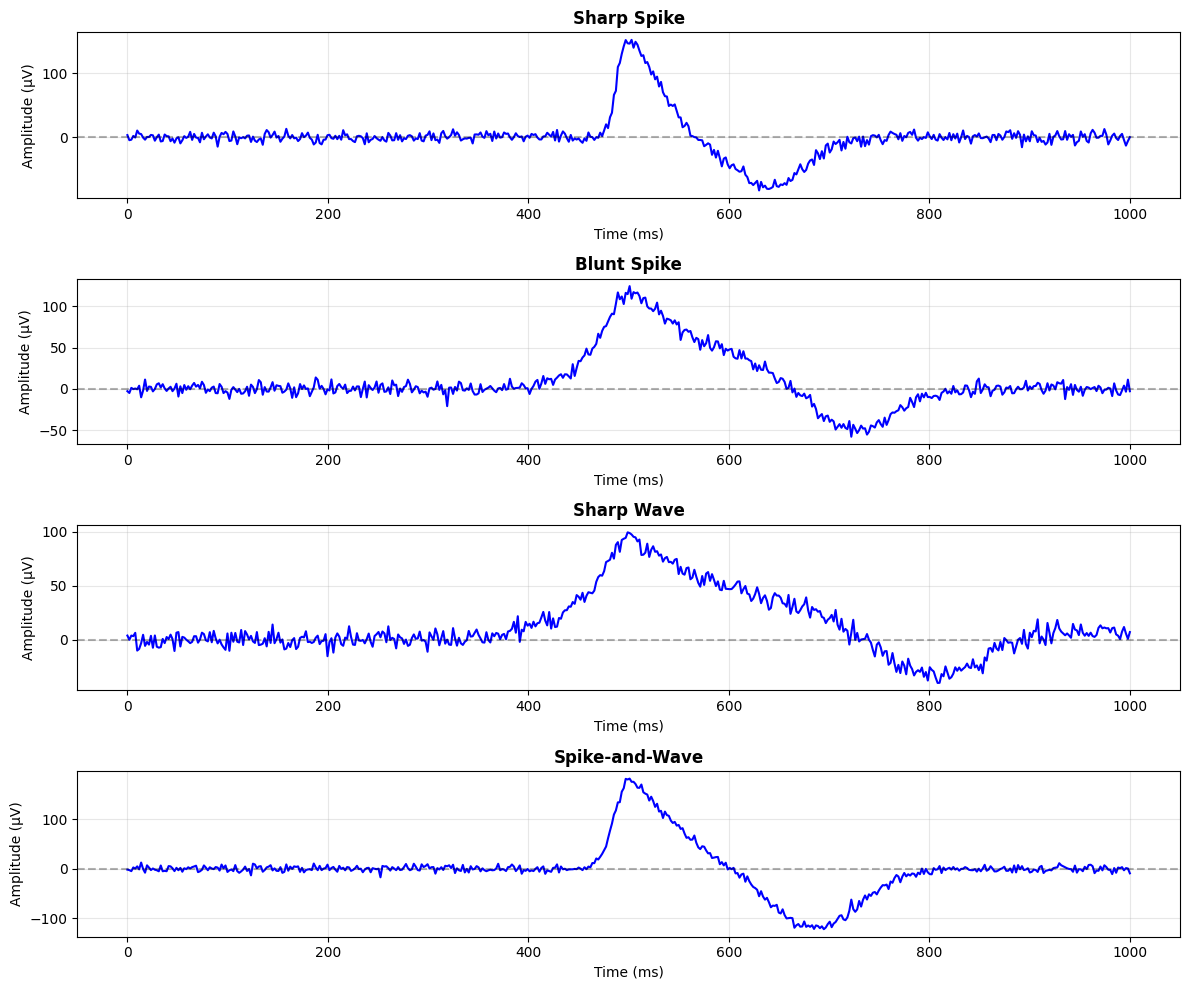

In [44]:
# @title
# Example usage
import matplotlib.pyplot as plt

gen = IEDWaveformGenerator(sampling_rate=512)

# Generate different IED types
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

presets = [
    ("Sharp Spike", PRESET_SHARP_SPIKE),
    ("Blunt Spike", PRESET_BLUNT_SPIKE),
    ("Sharp Wave", PRESET_SHARP_WAVE),
    ("Spike-and-Wave", PRESET_SPIKE_WAVE)
]

for ax, (name, params) in zip(axes, presets):
    time, waveform = gen.generate(params, duration=1.0)
    ax.plot(time * 1000, waveform, 'b-', linewidth=1.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (µV)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

MULTI-CHANNEL CROSS-CORRELATION ANALYSIS
Number of channels: 4
Sampling rate: 256 Hz
Time delay between channels: 10 ms
Amplitude decay: 0.7 per channel


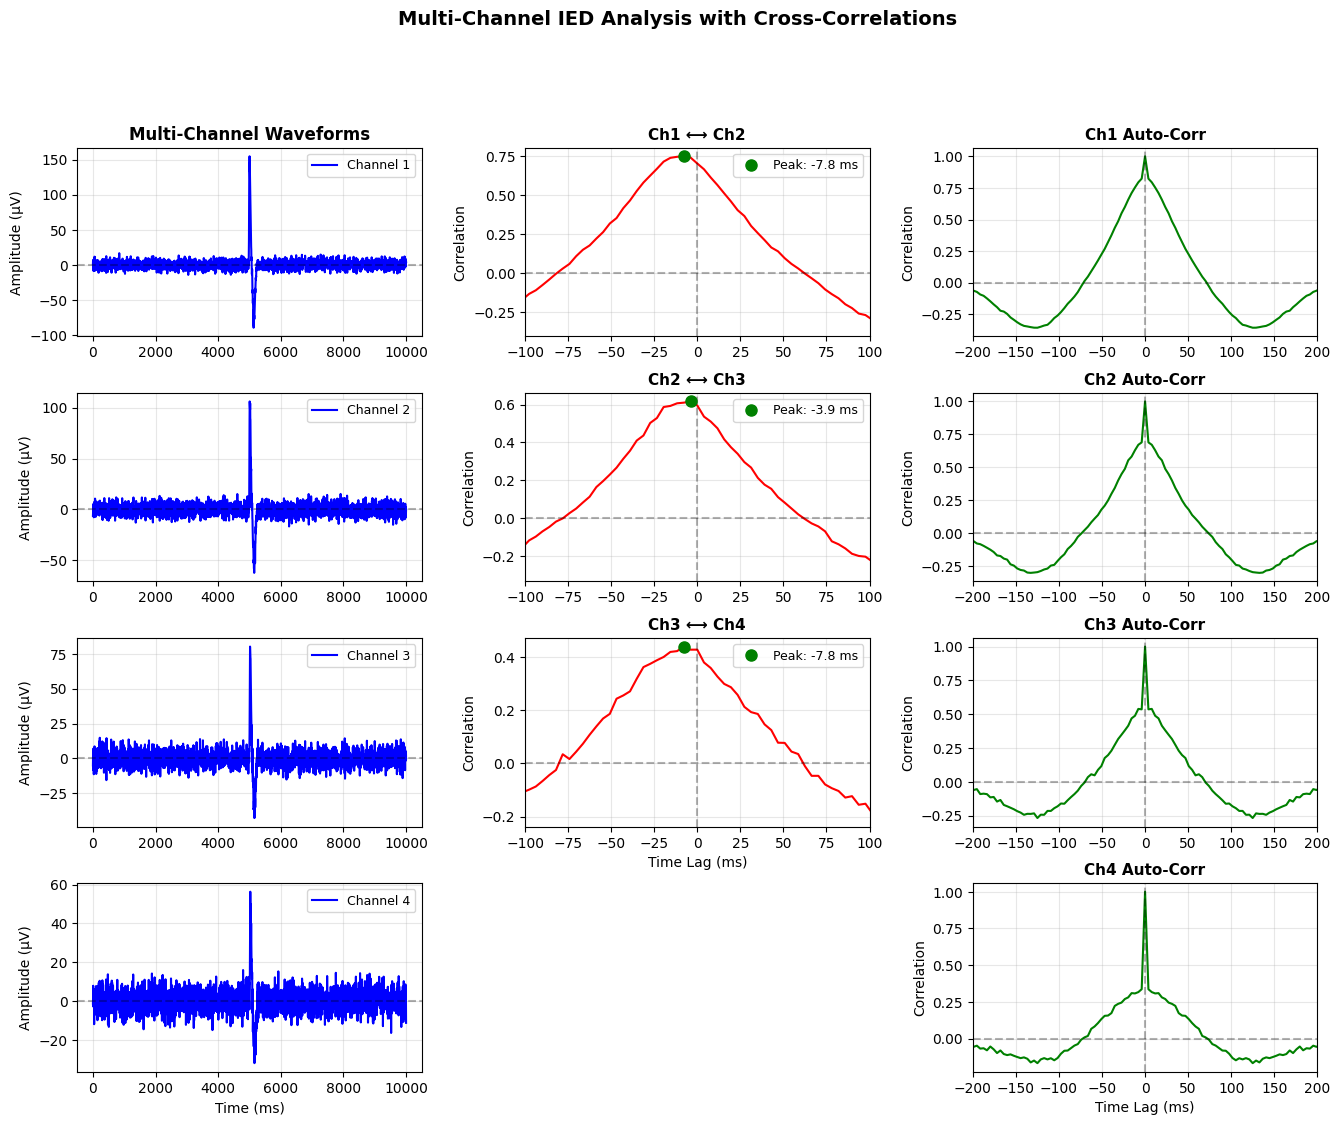

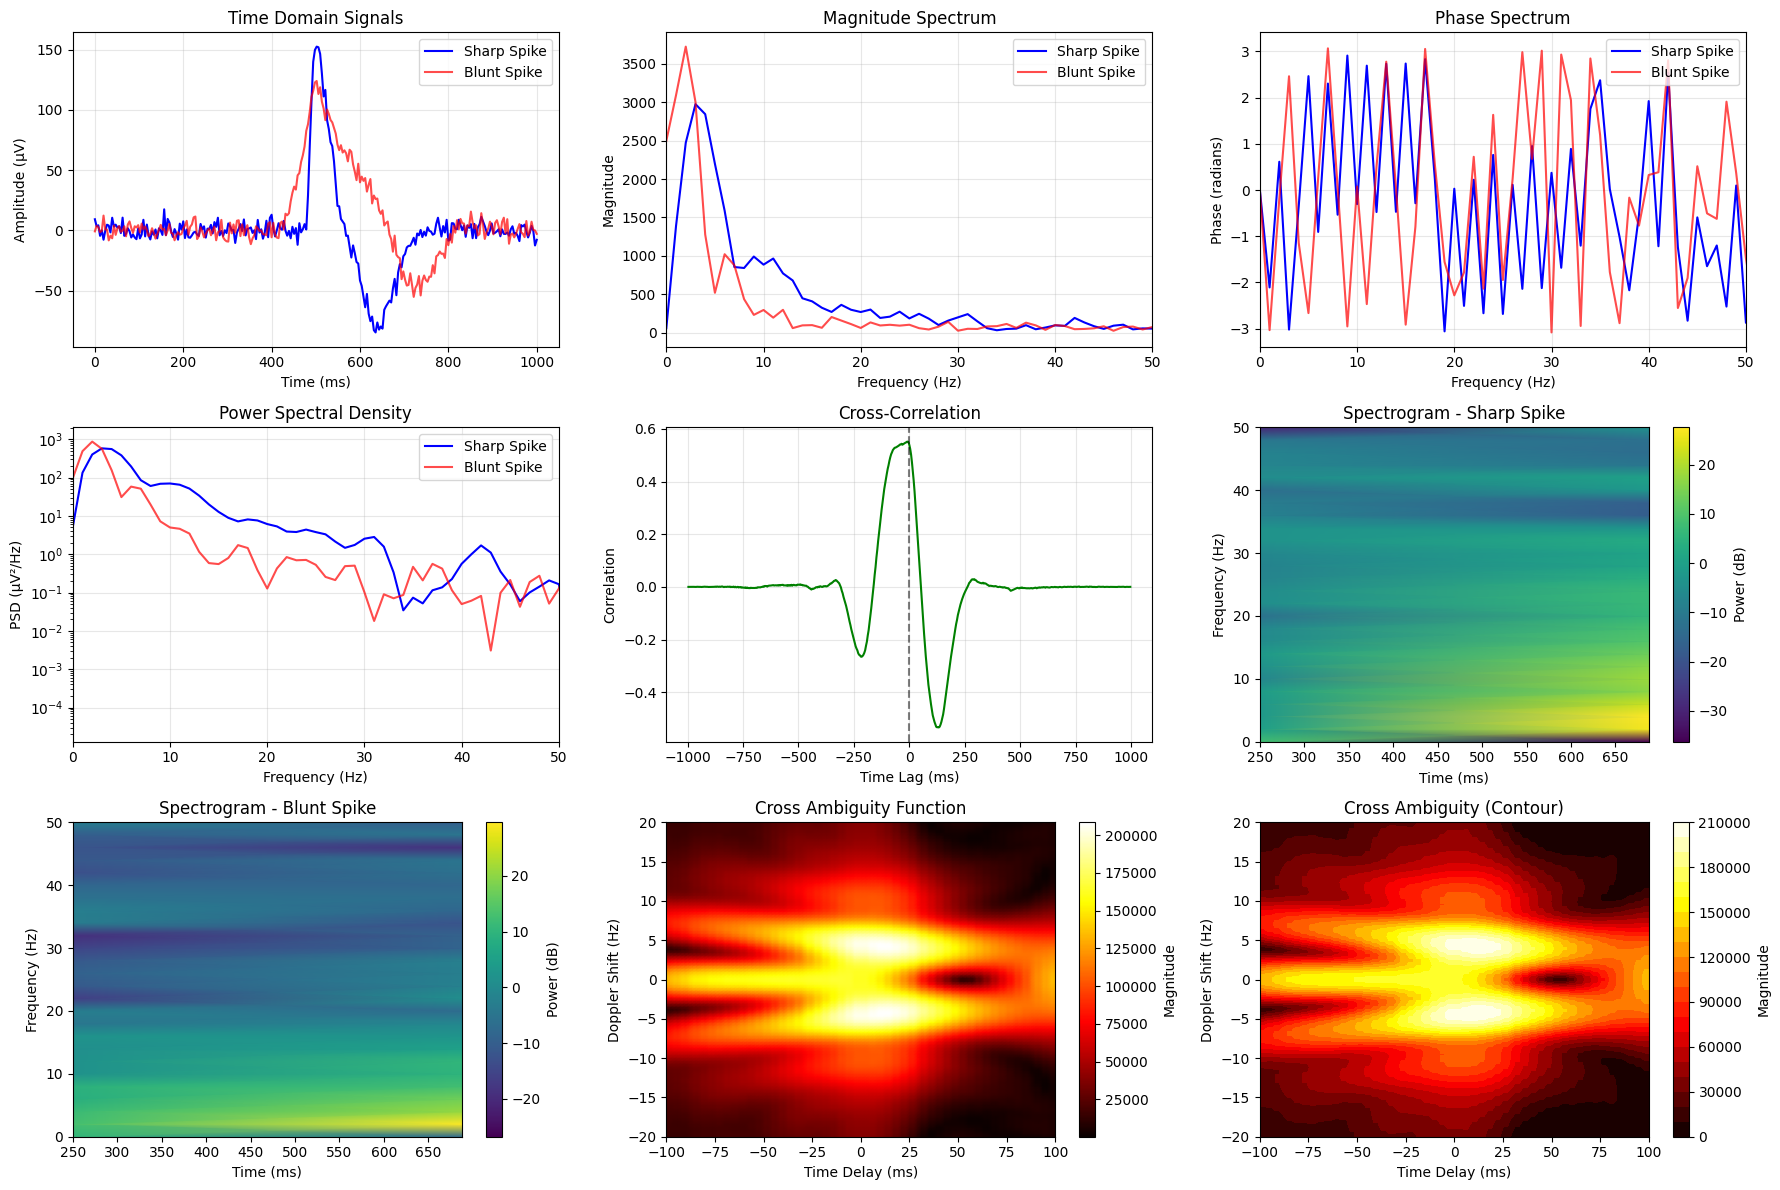

In [46]:
# @title
# Create generator
gen = IEDWaveformGenerator(sampling_rate=256)

# === Plot 1: Multi-channel cross-correlation ===
fig1, time, waveforms = plot_multi_channel_cross_correlation(
    gen,
    PRESET_SHARP_SPIKE,
    n_channels=4,
    duration=10.0
)

# Print delay information
print("=" * 60)
print("MULTI-CHANNEL CROSS-CORRELATION ANALYSIS")
print("=" * 60)
print(f"Number of channels: {waveforms.shape[1]}")
print(f"Sampling rate: {gen.sampling_rate} Hz")
print(f"Time delay between channels: 10 ms")
print(f"Amplitude decay: 0.7 per channel")
print("=" * 60)

# === Plot 2: Comprehensive analysis ===
fig2 = plot_all_analyses(
    gen,
    PRESET_SHARP_SPIKE,
    PRESET_BLUNT_SPIKE,
    labels=("Sharp Spike", "Blunt Spike")
)

plt.show()

### Solutions

Autocorrelation - Why?  
Correlation - typical attempt  
Ambiguity function? - correlation in 2D, where 1 is delays, other is some other such as "doppler, freq, or another variable"  

